## EXPERIMENTING WITH PYTORCH

In [77]:
import torch
import torch.optim as optim
import matplotlib.pyplot as plt

 IN MY OWN WORDS

|  x  |  w  | -> z , loss = z^2 

To propagate the error backwards, figure out what to adjust the weights by, 

loss.backward takes dL/dz (sensitivty of loss function to a change in z = 12),

multiplies it by the activation (technically transposed) to get the weight's gradient i.e, 12 * 3 = 36. 

What this is saying is that: 
    a) 12 (dL/dz) is the sensisitivy of the loss to a change in Z
    b) in turn the sensitivity of z to w weight was 3, because z = w * x, and deriving that wrt w is 1 * x (1 *3), then dz/dw is 12 * 3 = 36
    c) so the backpropagation is saying, nudging z down by 1 unit will nudge the loss down by 12 units, and because nudging w down by 1 unit will nudge z down by 3 units, so that means when i nudge w down 1, i nudge z down 3, which means loss is nudged down (12 * 3) or 36, so 1 nudge of w is 36 nudges of L, so the gradient (dL/dw) is 36

In [2]:
import numpy as np
import torch.nn.functional as F

In [3]:
#objects and functions

#nn.Linear(in_features, out_features) -- neural network layer with shape (in_features, out_features)



In [43]:
# n_neurons = [10,8,5,2,1]
# layers = {}

#manual method of initializing network 

def initialize_inputs(n_sample: int, n_features: int):
    #initialize seed here so we get a new random from the same starting position...
    rng = np.random.default_rng(42)

    sample_arr = rng.uniform(20, 100,[n_sample, n_features])

    
    sample_ts = torch.tensor(sample_arr, dtype=torch.float32)

    print("sample ts: ", sample_ts.shape)


    return sample_ts
        
            
                

Here, we initialize a neural net using the Pytorch neural network module, creating a class that inherits from the module, we can specifify each layer with the number of features in and out, (e.g. 3x 2)specify a bias, do a forward pass that takes in an input and does the multiplication? (self.layer(x)) we then instatiate our class to do so. 

In [ ]:
import torch 
import torch.nn as nn   

class TinyNet(nn.Module): 
    def __init__ (self, n_features, n_neurons):
        super().__init__()

        self.layers = nn.ModuleList() #modulelist is a collection-like object for layers 
        
        layer_input = n_features #first layer 


        #for each layer, create a layer with shape (layer_input, n), so that each layer has the right number of inputs and features
        for n in n_neurons:
            layer = nn.Linear(layer_input, n, bias=False) #layer takes in 'layer_input'inputs, and outputs n outbuts
            self.layers.append(layer)
            layer_input = n #the next number of neurons becomes the input 
            
        

    # the forward function is called as soon as our instance is defined because of __.call__ method, 
    # it goes through each layer in our collection of layers, calls the layer function which performs a matrix multiplication of layer inputs, 
    #before calling a ReLu activation function, except if we are at the last yayer 
    def forward(self, x):
        for i, layer in enumerate(self.layers):
            x = layer(x)
            if i < len(self.layers) -1: 
                x = F.relu(x)

        return x

n_features = 10
n_neurons = [10, 8, 5, 2, 1]

model = TinyNet(n_features, n_neurons)

for i, layer in enumerate(model.layers):
    print(f"layer {i}: {layer.weight.shape}")

layer_input 10
layer 0: torch.Size([10, 10])
layer 1: torch.Size([8, 10])
layer 2: torch.Size([5, 8])
layer 3: torch.Size([2, 5])
layer 4: torch.Size([1, 2])


In [42]:
test_sample = initialize_inputs (3, 10)
print(test_sample)             
print(type(test_sample[0]))
# x = torch.tensor([[3.0]]) 
output = model(test_sample)
print("output:", output)


sample ts:  torch.Size([3, 10])
tensor([[49.9632, 96.0571, 78.5595, 67.8927, 32.4815, 32.4796, 24.6467, 89.2941,
         68.0892, 76.6458],
        [21.6468, 97.5928, 86.5954, 36.9871, 34.5460, 34.6724, 44.3394, 61.9805,
         54.5556, 43.2983],
        [68.9482, 31.1595, 43.3716, 49.3089, 56.4856, 82.8141, 35.9739, 61.1388,
         67.3932, 23.7160]])
<class 'torch.Tensor'>
output: None


here we define a target (1x 1 matrix that's [10]), then we take advantage of TinyNet's __call__ method calls the forward method on x (3) (method multiplies it by the [1x1] weight in self.layer, we define our loss function, and then call Tiny Net's backward to do backpropagation. our loss is calculated (1.5 - 10)^2, and the resulting weight gradient is calculated, dL/dW 

In [ ]:
target = torch.tensor([[10.0]])

output = model(x)

loss = (output - target) ** 2
print("loss:", loss) 

loss.backward()
print("weight grad:", model.layer.weight.grad)

optimizer step...

looks like instead of our simple nudge of the weight by the gradient * learning rate, here we are using an optimizer SGD function that takes in model parameters (weights?) and the learning rate as argumnets , we peek into the weights in our one layer ([1x1], then we call optimizer's step method, which i think takes a step according to lr * the gradient we calculated in the previous step, we then check again to see how the weights change after the step, then we zero the accumulated gradients


In [ ]:
model = TinyNet()                       # fresh weight, fresh graph
optimizer = optim.SGD(model.parameters(), lr=0.01)
x = torch.tensor([[3.0]])
target = torch.tensor([[10.0]])

optimizer.zero_grad()                   # <-- zero FIRST, kills accumulation
output = model(x)
loss = (output - target) ** 2
loss.backward()

g = model.layer.weight.grad.item()
w_before = model.layer.weight.item()
optimizer.step()
w_after = model.layer.weight.item()

print(f"gradient      : {g:.4f}")
print(f"lr * gradient : {0.01 * g:.4f}")
print(f"weight before : {w_before:.4f}")
print(f"weight after  : {w_after:.4f}")
print(f"actual change : {w_after - w_before:.4f}")

TypeError: TinyNet.__init__() missing 2 required positional arguments: 'n_features' and 'n_neurons'

## Training using Diabetes Data


In [44]:
from sklearn.datasets import load_diabetes
import pandas as pd

# This dataset tracks disease progression based on age, bmi, bp, etc.
data = load_diabetes()
df = pd.DataFrame(data.data, columns=data.feature_names)

# cell 5
raw_target = data.target
scaled_target = (raw_target - raw_target.mean()) / raw_target.std()
diabetes_df = pd.concat([df, pd.Series(scaled_target, name='target')], axis=1)


In [57]:
diabetes_df[data.feature_names]

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641
...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930


layer_input 10
features: torch.Size([442, 10]) target: torch.Size([442, 1])


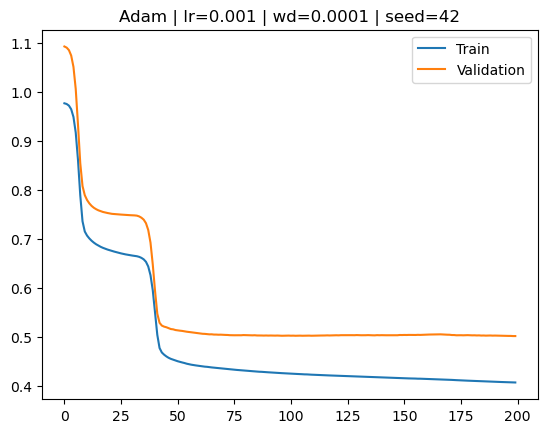

In [125]:
#0. Seed the init so as to be able compare runs 

torch.manual_seed(42)

# 1. SET UP NEURAL NETWORK 

#set no of features in dataset
n_features = len(diabetes_df[data.feature_names].columns)


#set no of neurons (reduced set of inputs that will be passed into each layer until we get to an output)
#set number of neurons in each layer until output = 1
n_neurons = [10, 8, 5, 2, 1]

#instantiate model with n_features and n_neurons
model = TinyNet(n_features, n_neurons)

#2. DEFINE OPTIMIZATION ALGORITHM

lr = 0.001
wd = 1e-4
optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=wd) #optimizer will do stochastic gradient descent each step, updating each learnable weight after each step

#3. TRANSFORM FEATURES AND TARGET DATA FROM DATAFRAME INTO NUMPY ARRAYS AND THEN INTO TENSORS

#create a tensor for the target, note that it must by in numpy array, which series already is 
#make sure data type is float32, because numpy is float64 and matmul will fail

target_ts = torch.tensor(diabetes_df['target'], dtype=torch.float32).reshape(-1,1)

#convert features dataset to numpy so that torch.tensor an read and convert to tensor 
features_arr = diabetes_df[data.feature_names].to_numpy()
features_ts = torch.tensor(features_arr, dtype = torch.float32)

print("features:", features_ts.shape, "target:", target_ts.shape) 

test_size = int(0.2 * features_ts.shape[0])

X_train_ts = features_ts[:-test_size]
X_test_ts = features_ts[-test_size:]

y_train_ts = target_ts[:-test_size]
y_test_ts = target_ts[-test_size:]



#set batch size, no. of epochs in preparation for training

batch_size = 10 
n_epochs = 200


#4. PER EPOCH AND PER BATCH, perform forward pass through our neutral network, matrix multiplication through the layers generates an output for each observation in the sample
epoch_counts = []
all_tr_loss = []
all_val_loss = []
for i in range(0, n_epochs):

    batch_tr_loss = []
    batch_val_loss = []
    
    for j in range(0, len(X_train_ts), batch_size):
        #zero out gradients to reset for each forward pass
        optimizer.zero_grad()

        batch = X_train_ts[j:j+batch_size]
        batch_output = model(batch)
        batch_true = y_train_ts[j:j+batch_size]

        loss = ((batch_output - batch_true) ** 2).mean()
        batch_tr_loss.append(loss.item())




        
        loss.backward()

        
        


        optimizer.step()

        # if i % 10 == 0:
        #     print(loss.item())


    
    #calculate the mean batch loss for the epoch
    epoch_tr_loss = np.mean(batch_tr_loss)

    #calculate validation loss over entire test set after each epoch
    with torch.no_grad():
        test = X_test_ts 
        test_output = model(test)
        test_true = y_test_ts

        epoch_val_loss = ((test_output - test_true) ** 2).mean()

    all_tr_loss.append(epoch_tr_loss)
    all_val_loss.append(epoch_val_loss.item())
    epoch_counts.append(i)

plt.plot(epoch_counts, all_tr_loss, label="Train")
plt.plot(epoch_counts, all_val_loss, label="Validation")
plt.title(f"Adam | lr={lr} | wd={wd} | seed=42")

plt.legend()
plt.show()
